# Brain plotting with NiSpace

NiSpace provides two standalone brain plotting functions from `nispace.plotting` that can be used independently of any colocalization analysis:

- `brainplot()` — renders parcellated DataFrames, NIfTI volumes, or GIfTI surface images on glass brains, anatomical slices, or inflated cortical surfaces.
- `view_surf()` — interactive 3D surface viewer (based on nilearn's `view_surf`).

These are the same functions that `nsp.plot_brain()` uses internally. Here we show how to use them directly, which is useful whenever you have brain maps to visualize outside of a NiSpace workflow — for example, for quality control, figure preparation, or just exploring a dataset.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nispace.plotting import brainplot, view_surf
from nispace.datasets import fetch_reference, fetch_example
from nispace.io import load_img

## `brainplot()` basics

The simplest use case: pass a NIfTI image and you get a plot. No parcellation needed.

<class 'nibabel.nifti1.Nifti1Image'>
WARNING | 20/07/26 18:22:34 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


(<Figure size 720x180 with 6 Axes>, [<Axes: >])

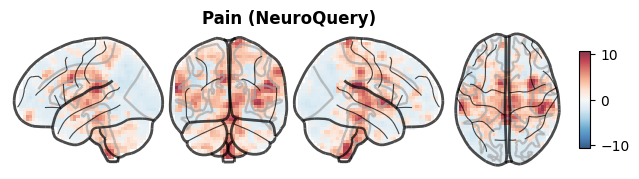

In [3]:
# load the pain map (a NIfTI image)
pain_map = load_img("neuroquery/pain.nii.gz")
print(type(pain_map))

# plot it — default rendering is glass brain for volumetric images
brainplot(pain_map, title="Pain (NeuroQuery)")

This works with a two-tuple of Gifti images, too (here, actually paths).

INFO | 20/07/26 18:22:35 | nispace.datasets: Fetching map info for dataset 'bigbrain'.


<class 'tuple'>
WARNING | 20/07/26 18:22:35 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


(<Figure size 800x220 with 2 Axes>, [<Axes: >])

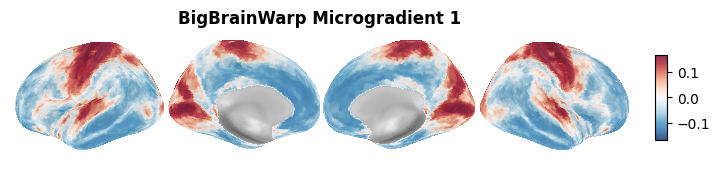

In [4]:
alpha_surf = fetch_reference("bigbrain", maps="microgradient1", space="fsaverage", verbose=False)[0]
print(type(alpha_surf))

# plot the surface maps, space should be passed as input to ensure correct rendering
brainplot(alpha_surf, title="BigBrainWarp Microgradient 1", space="fsaverage")

## Parcellated data

When you have parcellated data (a DataFrame or Series), pass the parcellation name or image alongside the data. NiSpace maps the parcel values back onto the brain.

INFO | 20/07/26 18:22:39 | nispace.datasets: Loading pet maps.


INFO | 20/07/26 18:22:39 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 20/07/26 18:22:39 | nispace.datasets: Filtering maps by collection.


INFO | 20/07/26 18:22:39 | nispace.datasets: Loading data parcellated with 'Yan200'


WARNING | 20/07/26 18:22:39 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


...

INFO | 20/07/26 18:22:39 | nispace.plotting: brainplot: threshold='auto' → 0.052574533969163895


INFO | 20/07/26 18:22:39 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.


INFO | 20/07/26 18:22:40 | nispace.core.parcellation: Parcellation 'Yan200': active space set to 'MNI152NLin2009cAsym'.


INFO | 20/07/26 18:22:40 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


(<Figure size 720x180 with 6 Axes>, [<Axes: >])

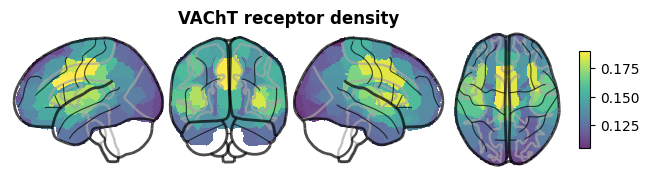

In [5]:
# fetch some PET maps, already parcellated
pet = fetch_reference("pet", parcellation="Yan200",
                      collection="UniqueTracers", print_references=False)

# plot a single map (select a Series by map-level name)
vacht = pet.loc[pet.index.get_level_values("map").str.contains("VAChT")].squeeze()

brainplot(vacht, parcellation="Yan200",
          title="VAChT receptor density", symmetric_cmap=False)

Opioid maps: ['target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020', 'target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018', 'target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015']
WARNING | 20/07/26 18:22:43 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 20/07/26 18:22:43 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010


INFO | 20/07/26 18:22:43 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage


INFO | 20/07/26 18:22:43 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.


INFO | 20/07/26 18:22:43 | nispace.plotting: brainplot: threshold='auto' → 0.010613149031996727


INFO | 20/07/26 18:22:43 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.


INFO | 20/07/26 18:22:43 | nispace.core.parcellation: Parcellation 'Yan200': active space set to 'MNI152NLin2009cAsym'.


INFO | 20/07/26 18:22:43 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


(<Figure size 2160x180 with 18 Axes>, [<Axes: >, <Axes: >, <Axes: >])

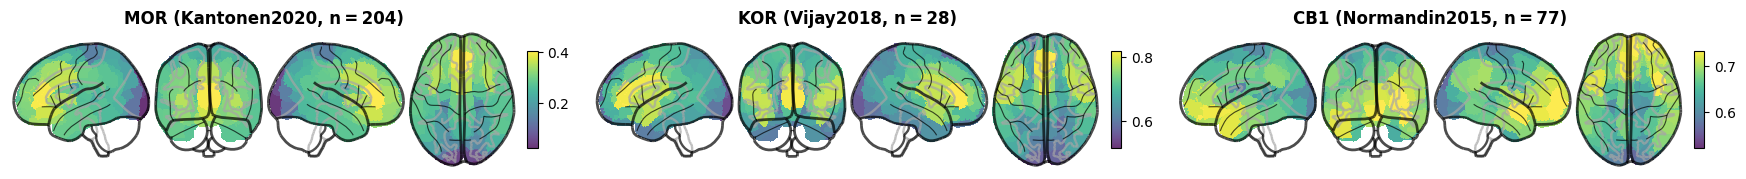

In [6]:
# plot multiple maps from a DataFrame
# select the opioid/endocannabinoid system maps
opioid_maps = pet.loc["Opioids/Endocannabinoids"]
print(f"Opioid maps: {list(opioid_maps.index)}")

brainplot(
    opioid_maps,
    parcellation="Yan200",
    symmetric_cmap=False,
    shared_colorscale=False,
    ncols=3
)

## Rendering modes

The `kind` argument controls how the brain is rendered.  

We currently have `"glass"`, `"slice"`, and `"surf"`.  
All these three options accept the `space` argument. For `"glass"` and `"slice"`, the two integrated MNI spaces are available (`"MNI152NLin2009cAsym"` and `"...6Asym"`); for `"surf"`, options are `"fsaverage"` and `"fsLR"` with their default meshes. Check the function reference for further information. 

These all use nilearn methods internally, but optimized for ease of use and very effective options to plot plot parcellated data. Also, every brain plot can easily be plotted into an axis as compared to only on figure level. If you are experienced with nilearn surface plotting, you might realize that the surfaces generate considerably faster. This is due to an internal tweak to nilearn's plot_surf function, improving array management.

### Glass brain plots

WARNING | 20/07/26 18:22:54 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


(<Figure size 720x180 with 6 Axes>, [<Axes: >])

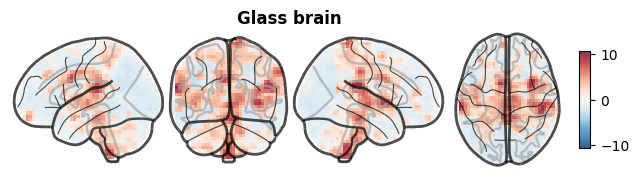

In [7]:
# glass brain (semi-transparent 3D volume)
brainplot(pain_map, kind="glass", title="Glass brain")

### Slice plots

WARNING | 20/07/26 18:22:56 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


(<Figure size 700x180 with 7 Axes>, [<Axes: >])

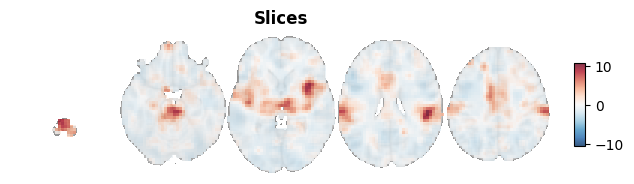

In [8]:
# anatomical slices
brainplot(pain_map, kind="slice", title="Slices")

WARNING | 20/07/26 18:22:58 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


(<Figure size 700x180 with 7 Axes>, [<Axes: >])

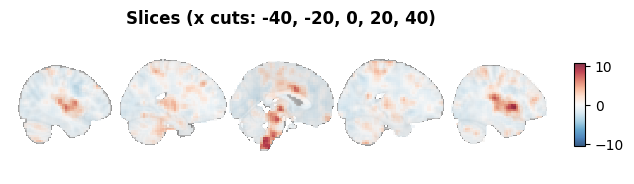

In [9]:
# the slice plots use nilearn.plotting.plot_img arguments for layout specification
brainplot(pain_map, kind="slice", title="Slices (x cuts: -40, -20, 0, 20, 40)", 
          display_mode="x", cut_coords=[-40, -20, 0, 20, 40])

### Surface plots

WARNING | 20/07/26 18:23:00 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 20/07/26 18:23:00 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010


INFO | 20/07/26 18:23:00 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage


INFO | 20/07/26 18:23:00 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.


INFO | 20/07/26 18:23:00 | nispace.plotting: brainplot: threshold='auto' → 0.052574533969163895


INFO | 20/07/26 18:23:00 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsaverage'.


INFO | 20/07/26 18:23:00 | nispace.core.parcellation: Parcellation 'Yan200': active space set to 'fsaverage'.


INFO | 20/07/26 18:23:00 | nispace.plotting: brainplot: kind='surface', img_mode='None', surf_space='fsaverage', mni_space='None', surf_mesh='inflated'


(<Figure size 800x220 with 2 Axes>, [<Axes: >])

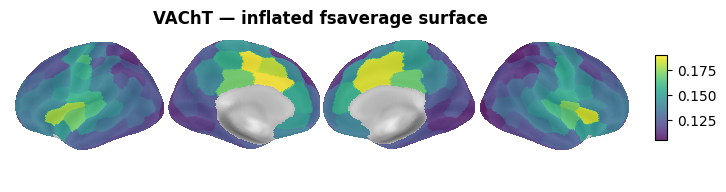

In [10]:
# inflated cortical surface (parcellated data), available: fsLR or fsaverage
brainplot(vacht, parcellation="Yan200",
          kind="surface", space="fsaverage", surf_mesh="inflated",
          symmetric_cmap=False, title="VAChT — inflated fsaverage surface")

WARNING | 20/07/26 18:23:05 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 20/07/26 18:23:05 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010


INFO | 20/07/26 18:23:05 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage


INFO | 20/07/26 18:23:05 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.


INFO | 20/07/26 18:23:05 | nispace.plotting: brainplot: threshold='auto' → 0.052574533969163895


INFO | 20/07/26 18:23:05 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.


INFO | 20/07/26 18:23:05 | nispace.core.parcellation: Parcellation 'Yan200': active space set to 'fsLR'.


INFO | 20/07/26 18:23:05 | nispace.plotting: brainplot: kind='surface', img_mode='None', surf_space='fsLR', mni_space='None', surf_mesh='midthickness'


(<Figure size 800x220 with 2 Axes>, [<Axes: >])

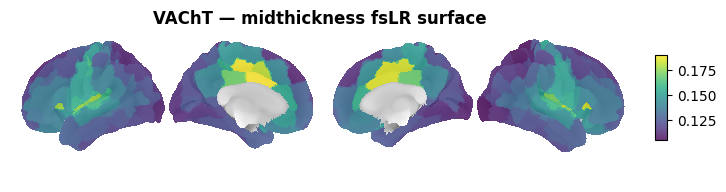

In [11]:
# fsLR midthickness surface
brainplot(vacht, parcellation="Yan200",
          kind="surface", space="fsLR", surf_mesh="midthickness",
          symmetric_cmap=False, title="VAChT — midthickness fsLR surface")

### Combined cortex-subcortex, and subcortex-only, plots

We have a parameter that we didn't talk about before: `level`.  
`level` can be `"cortex"`, `"subcortex"` or `"wholebrain"`, and a few aliases for these three.
The levels will mask the image (if volumetric) using a cortex and a subcortex mask, plotting either of these or both in two rows.  

Subcortical plots can currently be of kind `"glass"` or `"slice."`. 
Cortex plots can be all three possible kinds.  
Wholebrain plots expect a tuple for `kind`, or two kinds joint by `"+"`, e.g. `("surface", "glass")` or `"surface+glass"` (default).

NOTE: EARLY VERSION WITH BUGS, UNDERGOING REVISION

INFO | 20/07/26 18:23:09 | nispace.datasets: Fetching map info for dataset 'pet'.


WARNING | 20/07/26 18:23:09 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 20/07/26 18:23:09 | nispace.core.parcellation: Building combined Parcellation 'Yan200+TianS2' from library.


INFO | 20/07/26 18:23:09 | nispace.core.parcellation:   Common MNI space(s) for combined: ['MNI152NLin2009cAsym', 'MNI152NLin6Asym'].


INFO | 20/07/26 18:23:09 | nispace.core.parcellation:   Merging 'Yan200' and 'TianS2' for space 'MNI152NLin2009cAsym'.


...

INFO | 20/07/26 18:23:09 | nispace.plotting: brainplot: threshold='auto' → 0.11085913330316544


INFO | 20/07/26 18:23:10 | nispace.core.parcellation: Parcellation 'Yan200+TianS2': active space set to 'MNI152NLin2009cAsym'.


INFO | 20/07/26 18:23:10 | nispace.core.parcellation: Combined parcellation: cx-LH parcels = 100, cx-RH parcels = 100.


INFO | 20/07/26 18:23:10 | nispace.plotting: brainplot: kind='combined', img_mode='None', surf_space='fsLR', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


(<Figure size 800x320 with 6 Axes>,
 [<Axes: label='inset_axes'>, <Axes: label='inset_axes'>])

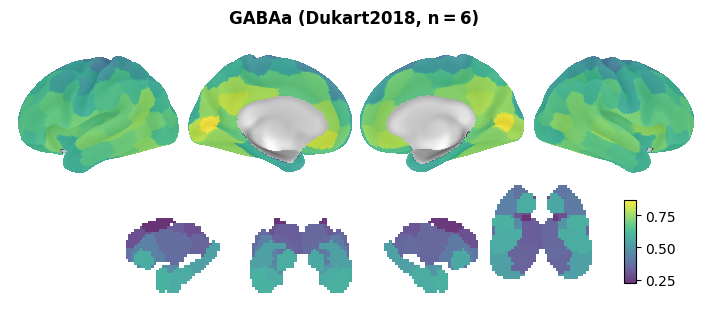

In [12]:
# cortex + subcortex data
gaba = fetch_reference(
    "pet", maps="GABAa_", parcellation="Yan200+TianS2", collection="UniqueTracers", verbose=False).squeeze()

# plot a combined plot using default settings 
brainplot(gaba, parcellation="Yan200+TianS2", level="combined")

WARNING | 20/07/26 18:23:15 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 20/07/26 18:23:15 | nispace.core.parcellation: Building combined Parcellation 'Yan200+TianS2' from library.


INFO | 20/07/26 18:23:15 | nispace.core.parcellation:   Common MNI space(s) for combined: ['MNI152NLin2009cAsym', 'MNI152NLin6Asym'].


INFO | 20/07/26 18:23:15 | nispace.core.parcellation:   Merging 'Yan200' and 'TianS2' for space 'MNI152NLin2009cAsym'.


INFO | 20/07/26 18:23:15 | nispace.core.parcellation:   Merging 'Yan200' and 'TianS2' for space 'MNI152NLin6Asym'.


...

INFO | 20/07/26 18:23:15 | nispace.plotting: brainplot: threshold='auto' → 0.11085913330316544


INFO | 20/07/26 18:23:15 | nispace.core.parcellation: Parcellation 'Yan200+TianS2': active space set to 'MNI152NLin2009cAsym'.


INFO | 20/07/26 18:23:15 | nispace.core.parcellation: Combined parcellation: cx-LH parcels = 100, cx-RH parcels = 100.


INFO | 20/07/26 18:23:15 | nispace.plotting: brainplot: kind='combined', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


(<Figure size 720x320 with 10 Axes>,
 [<Axes: label='inset_axes'>, <Axes: label='inset_axes'>])

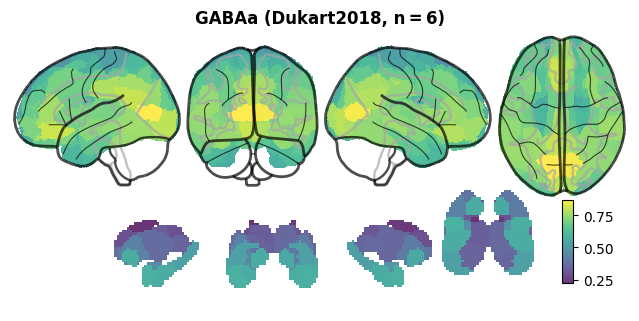

In [13]:
# plot a combined plot with glassbrain on top and bottom
brainplot(gaba, parcellation="Yan200+TianS2", level="combined", kind="glass+glass")

WARNING | 20/07/26 18:23:21 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 20/07/26 18:23:21 | nispace.core.parcellation: Building combined Parcellation 'Yan200+TianS2' from library.


INFO | 20/07/26 18:23:21 | nispace.core.parcellation:   Common MNI space(s) for combined: ['MNI152NLin2009cAsym', 'MNI152NLin6Asym'].


INFO | 20/07/26 18:23:21 | nispace.core.parcellation:   Merging 'Yan200' and 'TianS2' for space 'MNI152NLin2009cAsym'.


INFO | 20/07/26 18:23:21 | nispace.core.parcellation:   Merging 'Yan200' and 'TianS2' for space 'MNI152NLin6Asym'.


...

INFO | 20/07/26 18:23:21 | nispace.plotting: brainplot: threshold='auto' → 0.11085913330316544


INFO | 20/07/26 18:23:22 | nispace.core.parcellation: Parcellation 'Yan200+TianS2': active space set to 'MNI152NLin2009cAsym'.


INFO | 20/07/26 18:23:22 | nispace.core.parcellation: Combined parcellation: cx-LH parcels = 100, cx-RH parcels = 100.


INFO | 20/07/26 18:23:22 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


(<Figure size 720x180 with 6 Axes>, [<Axes: >])

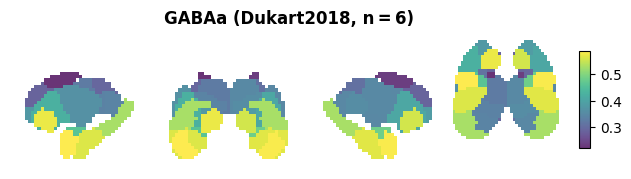

In [14]:
# plot only the subcortical part (this will restrict the colorscale to the subcortex)
brainplot(gaba, parcellation="Yan200+TianS2", level="subcortex")

## Black background

By default, the background of all plot types is white. With `black_bg=True`, we can set a black background, automatically adjusting all other elements, too.

WARNING | 20/07/26 18:23:24 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 20/07/26 18:23:24 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010


INFO | 20/07/26 18:23:24 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage


INFO | 20/07/26 18:23:24 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.


INFO | 20/07/26 18:23:24 | nispace.plotting: brainplot: threshold='auto' → 0.052574533969163895


INFO | 20/07/26 18:23:24 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.


INFO | 20/07/26 18:23:25 | nispace.core.parcellation: Parcellation 'Yan200': active space set to 'MNI152NLin2009cAsym'.


INFO | 20/07/26 18:23:25 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


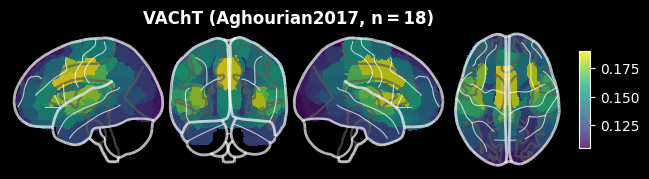

WARNING | 20/07/26 18:23:30 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 20/07/26 18:23:30 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010


INFO | 20/07/26 18:23:30 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage


INFO | 20/07/26 18:23:30 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.


INFO | 20/07/26 18:23:30 | nispace.plotting: brainplot: threshold='auto' → 0.052574533969163895


INFO | 20/07/26 18:23:30 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.


INFO | 20/07/26 18:23:30 | nispace.core.parcellation: Parcellation 'Yan200': active space set to 'MNI152NLin2009cAsym'.


INFO | 20/07/26 18:23:30 | nispace.plotting: brainplot: kind='slice', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


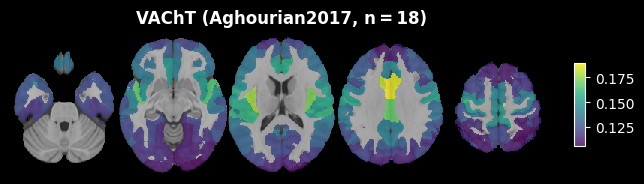

WARNING | 20/07/26 18:23:37 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 20/07/26 18:23:37 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010


INFO | 20/07/26 18:23:37 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage


INFO | 20/07/26 18:23:37 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.


INFO | 20/07/26 18:23:37 | nispace.plotting: brainplot: threshold='auto' → 0.052574533969163895


INFO | 20/07/26 18:23:37 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.


INFO | 20/07/26 18:23:37 | nispace.core.parcellation: Parcellation 'Yan200': active space set to 'fsLR'.


INFO | 20/07/26 18:23:37 | nispace.plotting: brainplot: kind='surface', img_mode='None', surf_space='fsLR', mni_space='None', surf_mesh='inflated'


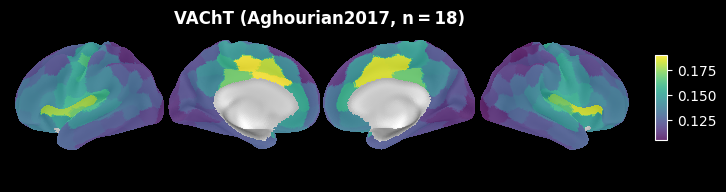

In [15]:
for kind in ["glass", "slice", "surface"]:
    brainplot(vacht, parcellation="Yan200", kind=kind, black_bg=True)
    plt.show()

## Colormap and scale options

WARNING | 20/07/26 18:23:39 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


(<Figure size 720x180 with 6 Axes>, [<Axes: >])

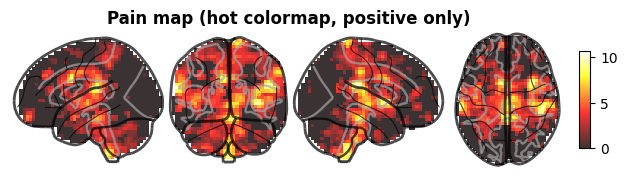

In [16]:
# custom colormap, threshold, and fixed scale
brainplot(
    pain_map,
    kind="glass",
    cmap="hot",
    symmetric_cmap=False,
    vmin=0,       # only show positive values
    threshold=0,  # explicitly threshold at 0
    title="Pain map (hot colormap, positive only)"
)

INFO | 20/07/26 18:23:41 | nispace.datasets: Loading enigmathick maps.


WARNING | 20/07/26 18:23:41 | nispace.datasets: Combined parcellation 'DesikanAseg' uses a deprecated naming format (concatenated or space-separated). Use the '+' separator or a tuple instead: 'DesikanKilliany+Aseg'. Support for the old format will be removed in the first non-dev release.


INFO | 20/07/26 18:23:41 | nispace.datasets: Loading and inner-merging data parcellated with 'DesikanKilliany' and 'Aseg'


INFO | 20/07/26 18:23:41 | nispace.datasets: Fetching map info for dataset 'enigmathick'.


The NiSpace "ENIGMAthick" dataset is based on ENIGMA analyses of brain structure across several
neuro-psychiatric disorders. The original data is provided via the ENIGMA Toolbox v2.0.3
(https://github.com/MICA-MNI/ENIGMA). It contains Cohen's d effect sizes (d_icv, largely ICV-
corrected) for case-vs-control differences in cortical thickness and subcortical volume. Cortical
values are provided in the Desikan parcellation, subcortical values in the Aseg parcellation. For
some disorders, effect size maps are split by subtype and/or age group. Use collection "Main" for a
reduced collection of the main effect size maps. For each disorder, please cite the appropriate
ENIGMA working group publication (see map info table).
  - Larivière et al., 2021  https://doi.org/10.1038/s41592-021-01186-4
To ensure reproducibility, note the NiSpace version: 0.0.2b2.dev48+g51f21588b.d20260717 (commit: g51f21588b).

  MDD        adult       1902.0  10.1038/mp.2016.60             https://doi.org/10.1038/mp.2

...

INFO | 20/07/26 18:23:42 | nispace.plotting: brainplot: threshold='auto' → 0.004999999888241291


INFO | 20/07/26 18:23:42 | nispace.core.parcellation: Parcellation 'DesikanKilliany+Aseg': active space set to 'MNI152NLin2009cAsym'.


INFO | 20/07/26 18:23:42 | nispace.core.parcellation: Combined parcellation: cx-LH parcels = 34, cx-RH parcels = 34.


INFO | 20/07/26 18:23:42 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


(<Figure size 720x630 with 18 Axes>, [<Axes: >, <Axes: >, <Axes: >])

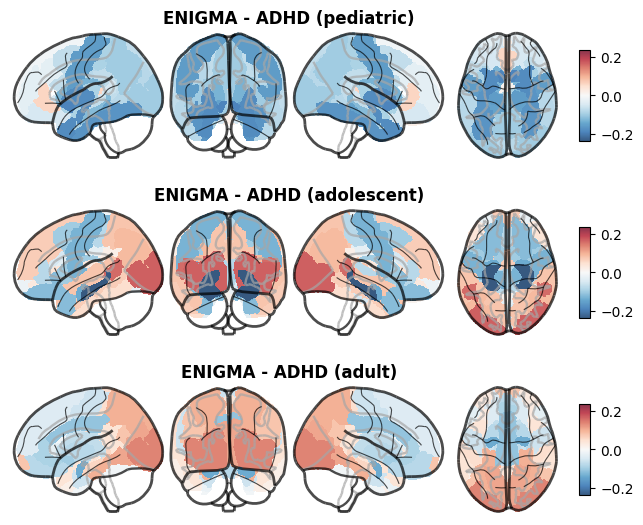

In [17]:
# shared color scale across multiple maps
# using the enigma dataset for illustration
enigma_data = fetch_reference("enigmathick", parcellation="DesikanAseg")

# select three maps based on index
enigma_data_to_plot = enigma_data.loc[[
    "dx-adhd_age-pediatric_pub-hoogman2019", 
    "dx-adhd_age-adolescent_pub-hoogman2019", 
    "dx-adhd_age-adult_pub-hoogman2019"
]]

# plot
brainplot(
    enigma_data_to_plot,
    parcellation="DesikanAseg",
    symmetric_cmap=True,
    shared_colorscale=True,  # same scale for all maps
    ncols=1,
    title=["ENIGMA - ADHD (pediatric)", "ENIGMA - ADHD (adolescent)", "ENIGMA - ADHD (adult)"]
)

## Using `brainplot()` inside a larger figure

Pass `fig` and `axes` to embed the plot inside an existing matplotlib figure.

WARNING | 20/07/26 18:23:51 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


WARNING | 20/07/26 18:23:54 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


WARNING | 20/07/26 18:23:58 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 20/07/26 18:23:58 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010


INFO | 20/07/26 18:23:58 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage


...

INFO | 20/07/26 18:24:11 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.


INFO | 20/07/26 18:24:11 | nispace.plotting: brainplot: threshold='auto' → 0.052574533969163895


INFO | 20/07/26 18:24:11 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.


INFO | 20/07/26 18:24:11 | nispace.core.parcellation: Parcellation 'Yan200': active space set to 'fsLR'.


INFO | 20/07/26 18:24:11 | nispace.plotting: brainplot: kind='surface', img_mode='None', surf_space='fsLR', mni_space='None', surf_mesh='inflated'


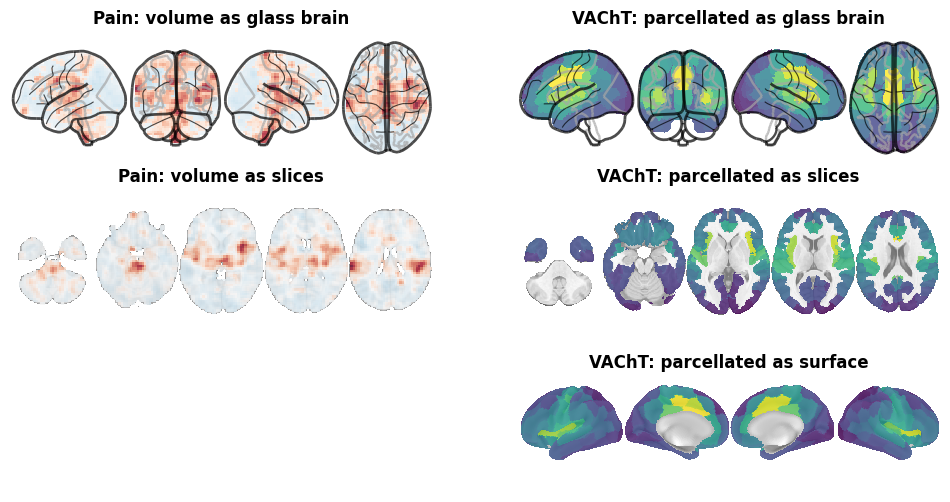

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(12, 6))

# column 1: pain map
brainplot(pain_map, kind="glass", fig=fig, axes=axes[0,0],
          title="Pain: volume as glass brain", colorbar=False)
brainplot(pain_map, kind="slice", fig=fig, axes=axes[1,0], cut_coords=[-40, -20, 0, 10, 20],
          title="Pain: volume as slices", colorbar=False)
axes[2,0].set_axis_off()

# columns 2: parcellated VAChT 
brainplot(vacht, parcellation="Yan200", kind="glass",
          symmetric_cmap=False, fig=fig, axes=axes[0,1],
          title="VAChT: parcellated as glass brain", colorbar=False)
brainplot(vacht, parcellation="Yan200", kind="slice", cut_coords=[-40, -20, 0, 10, 20],
          symmetric_cmap=False, fig=fig, axes=axes[1,1],
          title="VAChT: parcellated as slices", colorbar=False)
brainplot(vacht, parcellation="Yan200", kind="surface",
          symmetric_cmap=False, fig=fig, axes=axes[2,1],
          title="VAChT: parcellated as surface", colorbar=False)

plt.show()

## Plot a parcellation via the Parcellation class

The `Parcellation` class also uses `brainplot` to generate plots.

/var/folders/6n/h4150p8d5gz5kbnqv5_406940000gp/T/ipykernel_28381/4004943157.py:5: DeprecationWarning: Starting in version 0.13, the default fetched mask will beAAL 3v2 instead.
  parc = Parcellation.from_path(fetch_atlas_aal().maps)


[fetch_atlas_aal] Dataset found in /Users/llotter/nilearn_data/aal_SPM12


INFO | 20/07/26 18:24:14 | nispace.core.parcellation: Building Parcellation from path / image.


INFO | 20/07/26 18:24:14 | nispace.core.parcellation: Parcellation space: 'mni152'.


INFO | 20/07/26 18:24:14 | nispace.core.parcellation: Parcellation 'None': validation passed.


WARNING | 20/07/26 18:24:14 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


(<Figure size 720x180 with 5 Axes>, [<Axes: >])

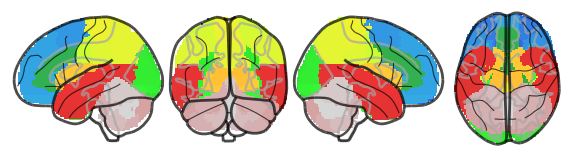

In [19]:
from nispace.core.parcellation import Parcellation
from nilearn.datasets import fetch_atlas_aal

# create the Parcellation object from a file path
parc = Parcellation.from_path(fetch_atlas_aal().maps)

# plot
parc.plot()

## Summary

**`brainplot()` key arguments:**

| Argument | What it does |
|----------|--------------|
| `data` | NIfTI image, GIfTI pair, DataFrame, or Series |
| `parcellation` | Required when `data` is tabular; a NiSpace name, file path, or image |
| `kind` | `"glass"`, `"slice"`, `"surface"`, `"combined"` |
| `cmap` | Any matplotlib colormap |
| `symmetric_cmap` | Zero-centered scale |
| `vmin`, `vmax` | Manual scale limits |
| `shared_colorscale` | Same scale across all maps in a DataFrame |
| `ncols` | Grid layout for multiple maps |
| `fig`, `axes` | Embed in existing matplotlib figure |

Next: [Notebook 9](intro09_workflows.ipynb) covers NiSpace's one-call workflow functions — the fastest way to run standard pipelines.